#### Optimal Portfolio Allocation of a Hybrid Energy to Hydrogen System

Running 500 Monte Carlo iterations


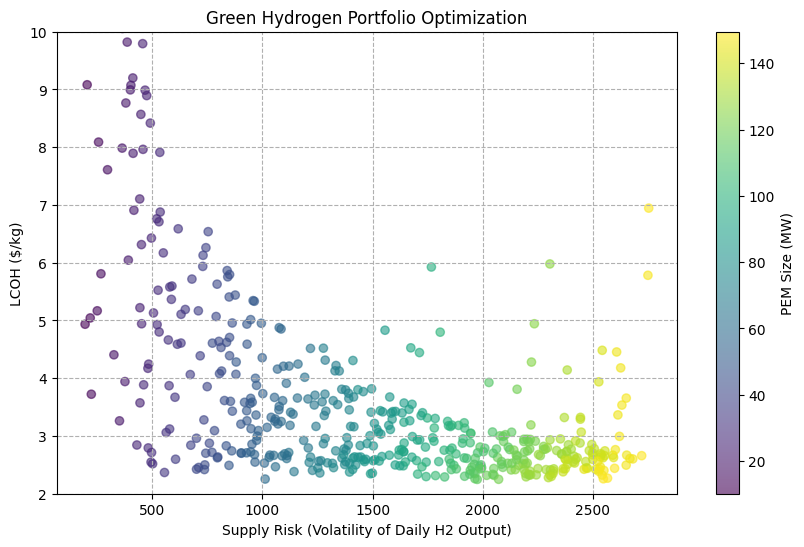

In [1]:
# import libraries that are necessary for this
import numpy as np
import pandas as pd
import scipy

# Planning ahead, so I know what blocks to look at
# 1. monte carlo sizing
# 2. hourly dispatch (8760 hrs)
# 3. financial metrics and plots

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The PEM electrolyzer physics module

class PEMElectrolyzer:
    def __init__(self, capacity_mw):
        self.capacity_mw = capacity_mw
        self.lhv_h2 = 33.33  # Lower Heating Value of H2 in kWh/kg
        self.min_part_load = 0.10  # 10% minimum safety threshold
        
    def calculate_production(self, power_in_mw):
        # check for zero or sub-threshold power
        load_factor = power_in_mw / self.capacity_mw
        
        # Empirical efficiency curve approximation: n(load) = -0.15*(load)^2 + 0.05*(load) + 0.70
        # This models higher efficiency (~70%) at low load, dropping at max load.
        efficiency = -0.15 * (load_factor**2) + 0.05 * load_factor + 0.70
        efficiency = np.clip(efficiency, 0.50, 0.75) # Bound it realistically
        
        # If below min part load, safety systems trip it off (0% efficiency)
        efficiency = np.where(load_factor < self.min_part_load, 0, efficiency)
        actual_power_used = np.where(load_factor < self.min_part_load, 0, power_in_mw)
        
        # Power (MW) * 1000 -> kW * 1 hour = kWh. 
        kwh_input = actual_power_used * 1000
        kg_h2 = (kwh_input * efficiency) / self.lhv_h2
        
        return kg_h2, efficiency

# Inner loop: hourly dispatch engine

def run_hourly_dispatch(solar_profile, grid_prices, p_solar_mw, e_bess_mwh, p_pem_mw):

    pem = PEMElectrolyzer(p_pem_mw)
    hours = len(solar_profile)
    
    # Scale normalized solar profile to this asset's capacity
    solar_gen = solar_profile * p_solar_mw
    
    # Initialize tracking arrays
    h2_produced = np.zeros(hours)
    grid_import = np.zeros(hours)
    bess_soc = 0.0  # Battery State of Charge (MWh)
    
    # Hourly Simulation Loop 
    for t in range(hours):
        avail_solar = solar_gen[t]
        current_grid_price = grid_prices[t]
        
        # Simple Rule-Based Dispatch Logic:
        # If grid price is cheap (< $20/MWh), buy power to boost PEM. 
        # If grid price is expensive (> $80/MWh), curtail PEM or sell solar back.
        if current_grid_price < 20:
            power_to_pem = min(avail_solar + (p_pem_mw * 0.5), p_pem_mw) # import some grid
            grid_import[t] = max(0, power_to_pem - avail_solar)
        else:
            power_to_pem = min(avail_solar, p_pem_mw)
            grid_import[t] = 0
            
        # Calculate physical hydrogen yield
        kg_h2, _ = pem.calculate_production(power_to_pem)
        h2_produced[t] = kg_h2
        
    # Financial Aggregations
    total_h2_kg = np.sum(h2_produced)
    
    # CAPEX Assumptions (2026 rough estimates)
    capex_solar = p_solar_mw * 800000     # $800k / MW
    capex_bess = e_bess_mwh * 250000     # $250k / MWh
    capex_pem = p_pem_mw * 1100000       # $1.1M / MW
    total_capex = capex_solar + capex_bess + capex_pem
    annualized_capex = total_capex / 20 # for 20 yrs
    
    # OPEX (Electricity cost)
    total_opex = np.sum(grid_import * grid_prices) + (total_capex * 0.02) # plus 2% fixed O&M
    
    lcoh = (annualized_capex + total_opex) / total_h2_kg if total_h2_kg > 0 else float('inf')
    
    # Risk Metric: Volatility of daily production 
    daily_h2 = h2_produced.reshape(-1, 24).sum(axis=1)
    production_volatility = np.std(daily_h2)
    
    return lcoh, production_volatility

# Outer loop: Monte Carlo sim
# Generate dummy data for 8760 hours 
np.random.seed(42)
dummy_solar = np.clip(np.sin(np.linspace(0, 2*np.pi*365, 8760)) + np.random.normal(0, 0.2, 8760), 0, 1)
dummy_grid_prices = np.random.normal(35, 15, 8760) # Avg $35/MWh with spikes

iterations = 500
results = []

print(f"Running {iterations} Monte Carlo iterations")
for i in range(iterations):
    # Randomly sample portfolio mixes
    sample_solar = np.random.uniform(10, 300)  # 10 to 300 MW
    sample_bess = np.random.uniform(0, 100)    # 0 to 100 MWh
    sample_pem = np.random.uniform(10, 150)    # 10 to 150 MW
    
    lcoh, risk = run_hourly_dispatch(dummy_solar, dummy_grid_prices, sample_solar, sample_bess, sample_pem)
    
    results.append({
        'solar_mw': sample_solar,
        'bess_mwh': sample_bess,
        'pem_mw': sample_pem,
        'lcoh': lcoh,
        'risk': risk
    })

df_res = pd.DataFrame(results)

# Plotting

plt.figure(figsize=(10, 6))
# Color the points by the size of the PEM stack to see trends
scatter = plt.scatter(df_res['risk'], df_res['lcoh'], c=df_res['pem_mw'], cmap='viridis', alpha=0.6)
plt.colorbar(scatter, label='PEM Size (MW)')
plt.title('Green Hydrogen Portfolio Optimization')
plt.xlabel('Supply Risk (Volatility of Daily H2 Output)')
plt.ylabel('LCOH ($/kg)')
plt.grid(True, linestyle='--')
plt.ylim(2, 10) # Typical green H2 cost boundaries
plt.show()